In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.7 MB/s eta 0:00:00


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import optuna
import shap
import time

In [ ]:
# Загрузка и подготовка данных
df = pd.read_csv("hypertension_dataset.csv")
df['Medication'] = df['Medication'].fillna('None')
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

# Масштабирование числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


# Optuna – это инструмент, предназначенный для автоматического подбора наилучших параметров для моделей машинного обучения.

Optuna выделяется использованием умных
алгоритмов, которые анализируют предыдущие попытки и сосредотачиваются
на наиболее перспективных областях параметров. По эффективности Optuna
превосходит Grid Search и Random Search. Фреймворк гибок в настройке
параметров, прост в использовании,
поддерживает
параллелизацию.

In [ ]:
def objective(trial):
    """Функция цели для Optuna, которая минимизирует ошибку (максимизирует точность)."""

    # Гиперпараметры для оптимизации
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }

    model = RandomForestClassifier(**params)
    # Используем кросс-валидацию для оценки качества
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()
    return score

# Запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Получение лучших результатов
best_params = study.best_params
print(f"Оптимальные гиперпараметры (Optuna): {best_params}")

# Обучение финальной модели
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# Оценка качества на тестовой выборке
y_pred = best_rf.predict(X_test)
print("\nОтчет по классификации (Оптимизированный RF на исходных данных):")
print(classification_report(y_test, y_pred))


[I 2025-11-11 16:20:46,986] A new study created in memory with name: no-name-fe57e79d-3161-4381-b9c4-88f4d7acbc04


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-11 16:20:51,224] Trial 0 finished with value: 0.9222320338674909 and parameters: {'n_estimators': 217, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.9222320338674909.
[I 2025-11-11 16:20:52,613] Trial 1 finished with value: 0.9582448120925642 and parameters: {'n_estimators': 123, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9582448120925642.
[I 2025-11-11 16:20:54,066] Trial 2 finished with value: 0.9647118406357945 and parameters: {'n_estimators': 106, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 2 with value: 0.9647118406357945.
[I 2025-11-11 16:20:54,912] Trial 3 finished with value: 0.9402332285795912 and parameters: {'n_estimators': 98, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 2 with value: 0.9647118406357945.
[I 2025

# Анализ информативности признаков

▎1. Feature Importances

Этот метод встроен в алгоритмы, такие как Random Forest и другие ансамблевые методы. Он предоставляет быстрый способ оценить относительную важность каждого признака на основе уменьшения неопределенности (impurity) в деревьях.
Результаты показывают, насколько каждый признак улучшает качество модели. Это позволяет быстро выявить ключевые факторы, влияющие на предсказания.

▎2. Permutation Importance

Этот метод не зависит от конкретной модели и может быть применен к любому классификатору. Permutation Importance измеряет изменение в качестве модели при случайном перемешивании значений признака. Это позволяет понять, насколько важен признак для предсказаний, а не только для структуры модели.
Метод помогает выявить взаимодействия между признаками, поскольку он показывает, как важность признака может меняться в зависимости от других признаков.

▎3. SHAP Values

SHAP (SHapley Additive exPlanations) предоставляет объяснения для каждого предсказания. Это позволяет понять, как каждый признак влияет на итоговое предсказание.
Метод основан на теории игр и дает справедливую оценку вкладов каждого признака, что делает его более обоснованным по сравнению с другими методами.
Использование summary plot (bar plot и distribution plot) позволяет визуализировать как глобальную важность признаков, так и их распределение по различным наблюдениям. Это помогает выявить не только наиболее важные признаки, но и их влияние на разные группы данных.

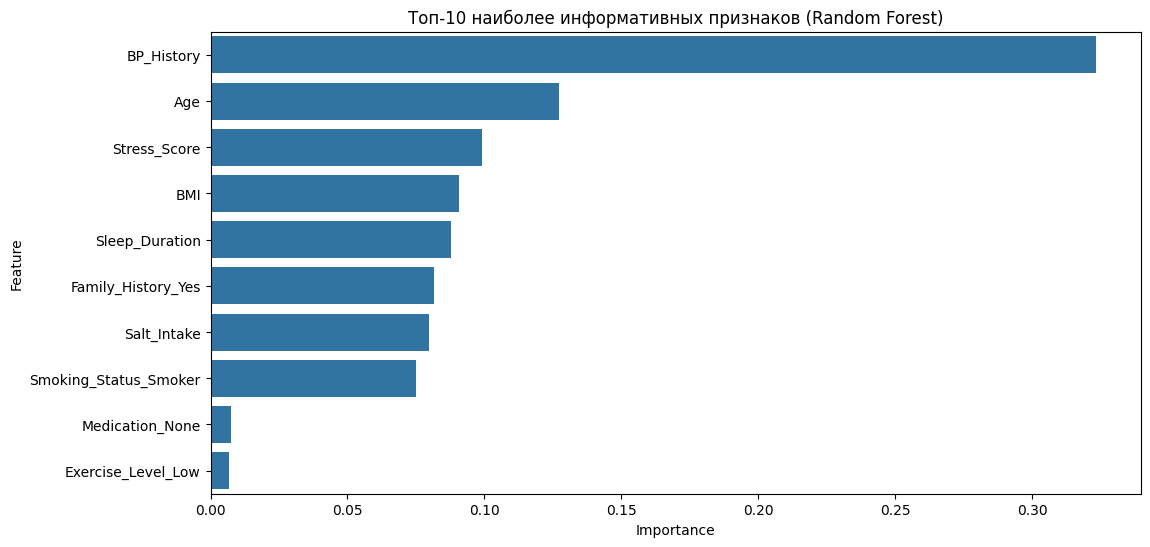


Топ-5 наиболее важных признаков (Random Forest):
          Feature  Importance
3      BP_History    0.323480
0             Age    0.127151
2    Stress_Score    0.099313
5             BMI    0.090661
4  Sleep_Duration    0.087942


In [ ]:
# Feature Importances
importances_rf = best_rf.feature_importances_
feature_names = X.columns
feature_importance_rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf_df.head(10))
plt.title('Топ-10 наиболее информативных признаков (Random Forest)')
plt.show()

print("\nТоп-5 наиболее важных признаков (Random Forest):")
print(feature_importance_rf_df.head(5))


## Анализ:
Самый информативный признак — BP_History (~ 0.32), т.е. наличие истории повышенного давления решающе для предсказания. Далее по значимости: Age (~ 0.12), Stress_Score (~ 0.10), BMI (~ 0.09), Sleep_Duration (~ 0.08–0.09). Средняя важность у Family_History, Salt_Intake и Smoking_Status (~ 0.06–0.08); низкая у Medication_None и Exercise_Level_Low (~ 0.01).

## Вывод:
Модель в первую очередь опирается на анамнез и возраст; значимы также стресс, вес и качество сна. Поведенческие факторы (соль, курение, активность) вносят вклад, но меньший.

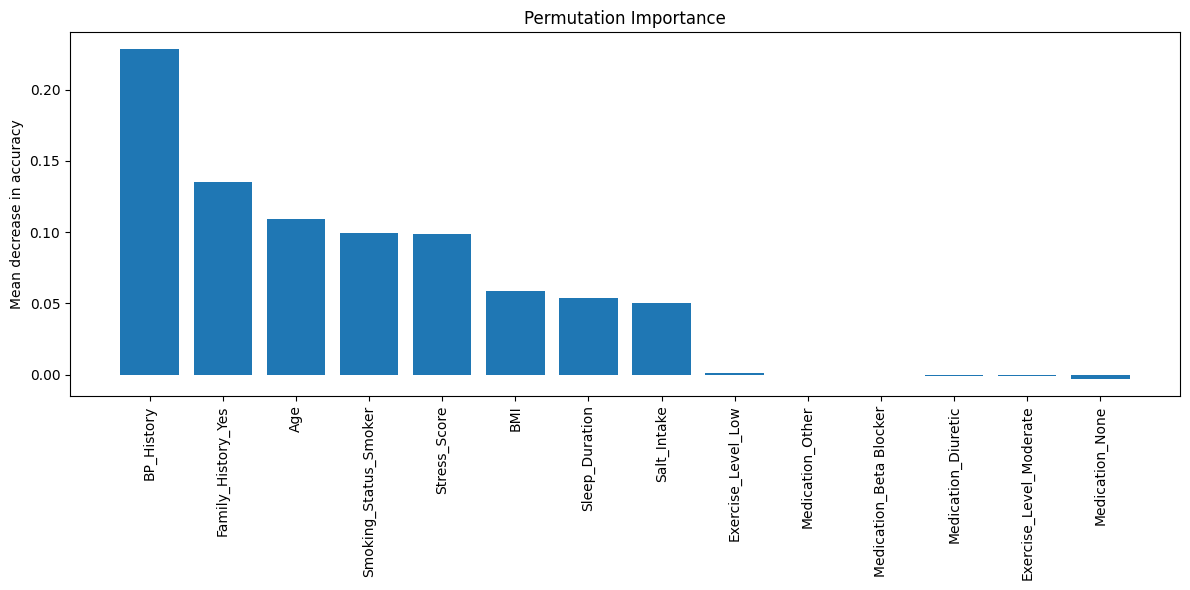


Топ-5 наиболее важных признаков (Permutation Importance):
                 Feature  Importance
0             BP_History    0.228523
1     Family_History_Yes    0.135403
2                    Age    0.109396
3  Smoking_Status_Smoker    0.099161
4           Stress_Score    0.098826


In [ ]:
# Permutation Importance
result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()[::-1]

plt.figure(figsize=(12, 6))
plt.bar(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xticks(rotation=90)
plt.title("Permutation Importance")
plt.ylabel("Mean decrease in accuracy")
plt.tight_layout()
plt.show()

# Вывод топ-5 признаков по Permutation Importance
permutation_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': result.importances_mean[sorted_idx]
})
print("\nТоп-5 наиболее важных признаков (Permutation Importance):")
print(permutation_importance_df.head(5))

## Анализ:
Самая важная переменная — BP_History (снижение точности ~ 0.23). Далее по значимости: Family_History_Yes, Age, Smoking_Status_Smoker, Stress_Score.
Средняя/малая значимость у BMI, Sleep_Duration, Salt_Intake (~ 0.05–0.06). Категории медикаментов и уровни упражнений практически не влияют (значение ≈ 0).
## Вывод:
Основные предикторы — история высокого давления, семейный анамнез, возраст и вредные привычки/стресс.

In [ ]:
# SHAP Values

# Создаем Explainer
explainer = shap.TreeExplainer(best_rf)

# Получаем SHAP значения.
shap_output = explainer.shap_values(X_test)

shap_values_processed = None
expected_value_processed = None

# Обработка различных возвращаемых типов shap_output
if isinstance(shap_output, np.ndarray):
    if shap_output.ndim == 3:
        shap_values_processed = shap_output[:, :, 1]
        if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 1:
            expected_value_processed = explainer.expected_value[1]
        else:
            expected_value_processed = explainer.expected_value
    elif shap_output.ndim == 2:
        shap_values_processed = shap_output
        if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 1:
            expected_value_processed = explainer.expected_value[1]
        else:
            expected_value_processed = explainer.expected_value
elif isinstance(shap_output, list):
    if len(shap_output) > 1:
        shap_values_processed = shap_output[1]
        if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 1:
            expected_value_processed = explainer.expected_value[1]
        else:
            expected_value_processed = explainer.expected_value
    else:
        shap_values_processed = shap_output[0]
        if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 0:
            expected_value_processed = explainer.expected_value[0]
        else:
            expected_value_processed = explainer.expected_value



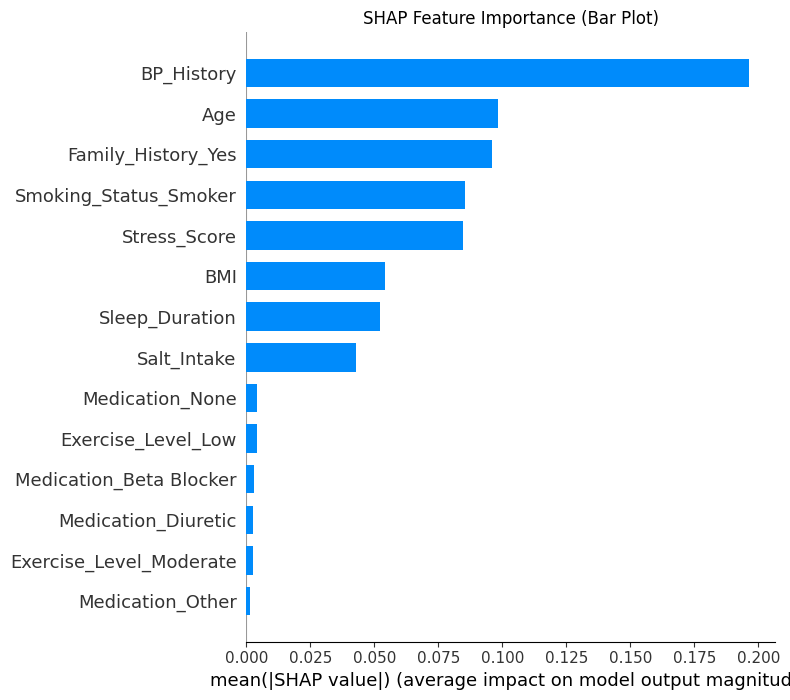

In [ ]:
# Глобальная важность признаков (summary plot - bar plot)
shap.summary_plot(shap_values_processed, X_test, plot_type="bar", feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()


## Анализ:
Самый важный признак — BP_History (в ~ 2–2.5 раза сильнее остальных).
Далее по значимости: Age и Family_History_Yes, затем Smoking_Status_Smoker и Stress_Score.
Средняя важность у BMI, Sleep_Duration и Salt_Intake.


## Вывод:
История артериального давления — ключевой фактор модели; на втором плане — возраст, семейный анамнез и вредные привычки/стресс.

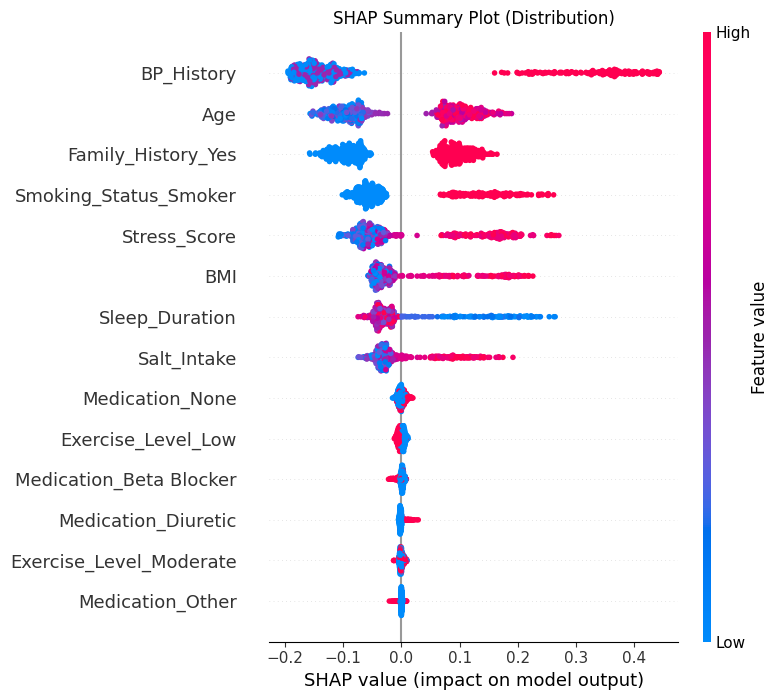

In [ ]:
# Глобальная важность признаков (summary plot - distribution plot)
shap.summary_plot(shap_values_processed, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Distribution)")
plt.tight_layout()
plt.show()

## Анализ:
Самые сильные факторы, повышающие прогнозируемый риск: наличие истории повышенного давления (BP_History), большой возраст, семейный анамнез (Family_History_Yes). Эти признаки дают самые большие положительные SHAP‑вклады.
Также существенно увеличивают риск: курение, высокий стресс, высокий BMI и  соль; низкая продолжительность сна тоже повышает риск (наоборот, больше сна — снижает вклад).
Факторы, связанные с приёмом лекарств и уровнем физ. активности, в модели влияют слабо.

## Вывод:
Модель в основном опирается на историю давления, возраст и семейный анамнез; наибольшие модифицирующие факторы — курение, стресс, BMI, соль и сон — значит.

## Итог:
- Ключевой фактор — наличие истории повышенного давления (BP_History), он значительно преобладает по влиянию во всех методах анализа.
- На втором месте по значимости — возраст и семейный анамнез (Family_History).
- Важное влияние оказывают стресс, курение, индекс массы тела (BMI), потребление соли и продолжительность сна (меньше сна повышает риск).
- Поведенческие факторы важны, но имеют меньшее влияние, а приём медикаментов и уровень физической активности в модели практически не влияют.

Модель в первую очередь опирается на медицинский анамнез (историю давления, возраст, семейные случаи), при этом поведенческие и образ жизни факторы играют дополнительную роль в формировании риска.